In [1]:
import pandas as pd 
import geopandas as gpd 
import numpy as np 

import os 
import sys 

from glob import glob 
from tqdm import tqdm 

In [2]:
ct_nyc = gpd.read_file("../aggregation/geo/data/ct-nyc-2020.geojson",crs="EPSG:4326").to_crs("EPSG:2263")


/share/ju/conda_virtualenvs/cambrian/lib/python3.10/site-packages/pyogrio/raw.py:196: RuntimeWarning: driver GeoJSON does not support open option CRS
  return ogr_read(


<Axes: >

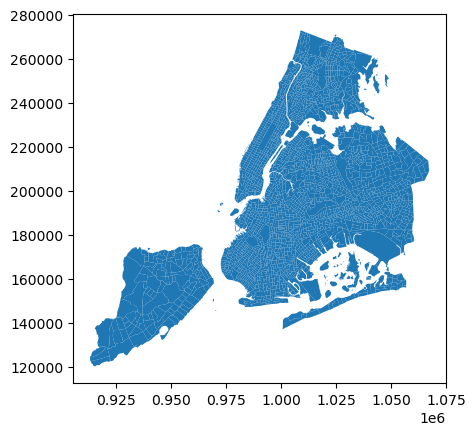

In [3]:
ct_nyc.plot()

In [4]:
entire_set = pd.read_csv("entire_sep29_all.csv", engine='pyarrow')

In [5]:
# how many images are have sentiment_1 1? 
entire_set[entire_set["sentiment_1"] == 1].shape

(1465, 8)

In [6]:
entire_md = pd.read_csv("/share/ju/urban-fingerprinting/output/default/df/2023-09-29/md.csv", engine='pyarrow')

In [6]:
entire_set['frame_id'] = entire_set['image_path'].apply(lambda x: x.split('/')[-1].split('.')[0].split('_')[-1])

In [7]:
entire_set['frame_id']

0         6bc60df5f33f5cf2294496d9f27502f3
1         dcea5a8493728ed92e82076cb314e2f5
2         c47a062296042caf805fe95df112d979
3         09dd1bcb9e346df3856f2172e610e396
4         12fca2907ef5099853aebd182a237ab3
                        ...               
926207    9d821c282c02e6ec3ba98777b32824ee
926208    37786df8890401b51100039725ab1d7a
926209    ca3fa4d857b65d1cae2725df78f6060b
926210    5c26c6aecd86f91a27f33cf6085a1bfc
926211    059aa4fa0a7a60da5f243a990753bc77
Name: frame_id, Length: 926212, dtype: object

In [8]:
entire_set = entire_md.merge(entire_set, on='frame_id', how='left')

In [9]:
entire_set = gpd.GeoDataFrame(entire_set, geometry=gpd.points_from_xy(entire_set['gps_info.longitude'], entire_set['gps_info.latitude'], crs='EPSG:4326')).to_crs('EPSG:2263')

In [10]:
entire_set.describe()

,,camera_heading,captured_at,timezone_offset,h3_index_res12,frame_quality,gps_info.longitude,gps_info.latitude,osm_info.osm_node_id_from,osm_info.osm_node_id_to,h3_12,h3_index_res06,Unnamed: 0.1,sentiment_1,sentiment_2
count,926212.000000,926212.000000,9.262120e+05,926212.0,9.262120e+05,926212.000000,926212.000000,926212.000000,9.262120e+05,9.262120e+05,9.208310e+05,9.262120e+05,406.000000,926212.000000,926212.000000
mean,28712.949361,179.559775,1.696009e+12,-14400.0,6.312439e+17,0.797860,-73.918321,40.725298,4.375140e+09,4.456266e+09,6.312439e+17,6.042223e+17,202.500000,0.001582,0.146341
std,26410.010055,105.739324,1.190899e+07,0.0,1.212162e+10,0.090021,0.079832,0.069577,3.872608e+09,3.894543e+09,1.212618e+10,1.211954e+10,117.346353,0.039739,0.353448
min,0.000000,-1.000000,1.695960e+12,-14400.0,6.312439e+17,0.600002,-74.252436,40.501651,3.375199e+07,3.375199e+07,6.312439e+17,6.042223e+17,0.000000,0.000000,0.000000
25%,9500.000000,85.247789,1.695999e+12,-14400.0,6.312439e+17,0.733977,-73.977392,40.676344,2.775759e+08,2.775765e+08,6.312439e+17,6.042223e+17,101.250000,0.000000,0.000000
50%,22316.000000,185.798943,1.696010e+12,-14400.0,6.312439e+17,0.797787,-73.930622,40.726174,4.205052e+09,4.207864e+09,6.312439e+17,6.042223e+17,202.500000,0.000000,0.000000
75%,39158.000000,271.953918,1.696019e+12,-14400.0,6.312439e+17,0.860643,-73.861933,40.764087,8.282796e+09,8.309479e+09,6.312439e+17,6.042223e+17,303.750000,0.000000,0.000000
max,133965.000000,360.000000,1.696046e+12,-14400.0,6.312440e+17,1.000000,-73.699181,40.915799,1.031553e+10,1.031553e+10,6.312440e+17,6.042224e+17,405.000000,1.000000,1.000000


In [11]:
# merge entire_set with cts_nyc 
entire_set = gpd.sjoin_nearest(entire_set, ct_nyc)


In [12]:
entire_set.describe()

,,camera_heading,captured_at,timezone_offset,h3_index_res12,frame_quality,gps_info.longitude,gps_info.latitude,osm_info.osm_node_id_from,osm_info.osm_node_id_to,h3_12,h3_index_res06,Unnamed: 0.1,sentiment_1,sentiment_2,index_right,OBJECTID,Shape__Area,Shape__Length
count,926259.000000,926259.000000,9.262590e+05,926259.0,9.262590e+05,926259.000000,926259.000000,926259.000000,9.262590e+05,9.262590e+05,9.208770e+05,9.262590e+05,406.000000,926259.000000,926259.000000,926259.000000,926259.000000,9.262590e+05,926259.000000
mean,28712.235880,179.557767,1.696009e+12,-14400.0,6.312439e+17,0.797859,-73.918321,40.725303,4.375186e+09,4.456327e+09,6.312439e+17,6.042223e+17,202.500000,0.001582,0.146336,1273.955268,1274.955268,1.035448e+07,13416.243549
std,26409.752956,105.739114,1.190892e+07,0.0,1.212159e+10,0.090020,0.079830,0.069581,3.872622e+09,3.894550e+09,1.212616e+10,1.211951e+10,117.346353,0.039738,0.353443,747.125842,747.125842,3.039992e+07,17739.198356
min,0.000000,-1.000000,1.695960e+12,-14400.0,6.312439e+17,0.600002,-74.252436,40.501651,3.375199e+07,3.375199e+07,6.312439e+17,6.042223e+17,0.000000,0.000000,0.000000,1.000000,2.000000,4.005503e+05,2569.477865
25%,9499.000000,85.241955,1.695999e+12,-14400.0,6.312439e+17,0.733978,-73.977392,40.676345,2.775759e+08,2.775765e+08,6.312439e+17,6.042223e+17,101.250000,0.000000,0.000000,644.000000,645.000000,1.857829e+06,5774.682935
50%,22316.000000,185.783354,1.696010e+12,-14400.0,6.312439e+17,0.797788,-73.930621,40.726176,4.205052e+09,4.207864e+09,6.312439e+17,6.042223e+17,202.500000,0.000000,0.000000,1283.000000,1284.000000,2.420866e+06,7518.421409
75%,39157.000000,271.953873,1.696019e+12,-14400.0,6.312439e+17,0.860643,-73.861935,40.764092,8.284087e+09,8.309479e+09,6.312439e+17,6.042223e+17,303.750000,0.000000,0.000000,1999.000000,2000.000000,5.059222e+06,11719.199811
max,133965.000000,360.000000,1.696046e+12,-14400.0,6.312440e+17,1.000000,-73.699181,40.915799,1.031553e+10,1.031553e+10,6.312440e+17,6.042224e+17,405.000000,1.000000,1.000000,2324.000000,2325.000000,1.971892e+08,148837.372360


In [ ]:
inspection_set_annotated = pd.read_csv("../data/processed/inspection_set.csv")

In [14]:
inspection_set_annotated['frame_id'] = inspection_set_annotated['image'].apply(lambda x: x.split('/')[-1].split('.')[0].split('_')[-1])
inspection_set_annotated['choice'] = inspection_set_annotated['choice'].apply(lambda x: 1 if x == 'Flooded road' else 0)
# drop everything except frame_id and choice 
inspection_set_annotated['pred'] = inspection_set_annotated['sentiment_1']

inspection_set_annotated['tp'] = ((inspection_set_annotated['choice'] == 1) & (inspection_set_annotated['pred'] == 1)).astype(int)
inspection_set_annotated['fp'] = ((inspection_set_annotated['choice'] == 0) & (inspection_set_annotated['pred'] == 1)).astype(int)
inspection_set_annotated['tn'] = ((inspection_set_annotated['choice'] == 0) & (inspection_set_annotated['pred'] == 0)).astype(int)
inspection_set_annotated['fn'] = ((inspection_set_annotated['choice'] == 1) & (inspection_set_annotated['pred'] == 0)).astype(int)

inspection_set_annotated = inspection_set_annotated[['frame_id', 'choice', 'pred', 'tp', 'fp', 'tn', 'fn']]


inspection_set_annotated.describe()

,choice,pred,tp,fp,tn,fn
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.332000,0.50000,0.329000,0.171000,0.497000,0.003000
std,0.471167,0.50025,0.470085,0.376697,0.500241,0.054717
min,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.50000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,1.00000,1.000000,0.000000,1.000000,0.000000
max,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000


In [15]:
# merge inspection_set_annotated with entire_set
entire_set = entire_set.merge(inspection_set_annotated, on='frame_id', how='left')
entire_set.isna().sum()

                                  0
frame_id                          0
frame_url                         0
camera_heading                    0
captured_at                       0
timezone_offset                   0
h3_index_res12                    0
thumbnail_url                     0
direction                         0
frame_quality                     0
frame_context                     0
gps_info.longitude                0
gps_info.latitude                 0
osm_info.osm_node_id_from         0
osm_info.osm_node_id_to           0
osm_info.road_type                0
h3_12                          5382
h3_index_res06                    0
geometry                          0
image_path                        0
q1                                0
q2                                0
response_1                        0
response_2                        0
Unnamed: 0.1                 925853
sentiment_1                       0
sentiment_2                       0
index_right                 

In [16]:
# get number of total images and number of sentiment_1 == 1 images in each census tract 
by_ct = entire_set.groupby('BoroCT2020').agg({'frame_id':'count', 'sentiment_1':'sum', 'tp': 'sum', 'fp': 'sum', 'tn': 'sum', 'fn': 'sum' }).fillna(0).reset_index()
by_ct.columns = ['BoroCT2020', 'n_total', 'n_classified_positive', 'n_tp', 'n_fp', 'n_tn', 'n_fn']

In [17]:
ct_nyc = ct_nyc.merge(by_ct, on='BoroCT2020', how='left').fillna(0) 

/tmp/ipykernel_426437/3908676694.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ct_nyc = ct_nyc.merge(by_ct, on='BoroCT2020', how='left').fillna(0)


In [18]:
ct_nyc['n_classified_positive'].describe() 

count    2325.000000
mean        0.630108
std         2.631392
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        60.000000
Name: n_classified_positive, dtype: float64

In [19]:
ct_nyc['n_classified_positive'].sum()

1465.0

In [20]:
ct_nyc['n_total'].describe()

count     2325.000000
mean       398.390968
std        741.446688
min          0.000000
25%        120.000000
50%        220.000000
75%        442.000000
max      20941.000000
Name: n_total, dtype: float64

In [21]:
ct_nyc['n_total'].sum()

926259.0

In [22]:
ct_nyc['n_tp'].sum()

329.0

In [23]:
ct_nyc['n_fp'].sum()

171.0

In [24]:
ct_nyc['n_tn'].sum()

497.0

In [25]:
ct_nyc['n_fn'].sum()

3.0

In [26]:
ct_nyc['total_not_annotated'] = ct_nyc['n_total'] - (ct_nyc['n_tp'] + ct_nyc['n_fp'] + ct_nyc['n_tn'] + ct_nyc['n_fn'])
# CHECK CODE HERE, send emma descriptive stats of updated ct level dataset
ct_nyc['positives_not_annotated'] = ct_nyc['n_classified_positive'] - (ct_nyc['n_tp'] + ct_nyc['n_fp'])
ct_nyc['negatives_not_annotated'] = ct_nyc['n_total'] - ct_nyc['n_classified_positive'] - ct_nyc['n_fn']

In [27]:
ct_nyc['total_not_annotated'].describe()

count     2325.000000
mean       397.960860
std        740.406155
min          0.000000
25%        120.000000
50%        220.000000
75%        442.000000
max      20905.000000
Name: total_not_annotated, dtype: float64

In [28]:
ct_nyc['positives_not_annotated'].describe()

count    2325.000000
mean        0.415054
std         1.795058
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        39.000000
Name: positives_not_annotated, dtype: float64

In [29]:
ct_nyc['negatives_not_annotated'].describe()

count     2325.000000
mean       397.759570
std        739.763334
min          0.000000
25%        120.000000
50%        220.000000
75%        442.000000
max      20881.000000
Name: negatives_not_annotated, dtype: float64

In [30]:
ct_nyc 

,OBJECTID,CTLabel,BoroCode,BoroName,CT2020,BoroCT2020,CDEligibil,NTAName,NTA2020,CDTA2020,...,geometry,n_total,n_classified_positive,n_tp,n_fp,n_tn,n_fn,total_not_annotated,positives_not_annotated,negatives_not_annotated
0,1,1,1,Manhattan,000100,1000100,0,The Battery-Governors Island-Ellis Island-Libe...,MN0191,MN01,...,"MULTIPOLYGON (((972081.348 190736.594, 972184....",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,2.01,1,Manhattan,000201,1000201,0,Chinatown-Two Bridges,MN0301,MN03,...,"POLYGON ((988547.777 197773.565, 987978.366 19...",345.0,0.0,0.0,0.0,0.0,0.0,345.0,0.0,345.0
2,3,6,1,Manhattan,000600,1000600,0,Chinatown-Two Bridges,MN0301,MN03,...,"POLYGON ((986960.738 199556.833, 987205.692 19...",908.0,2.0,1.0,0.0,1.0,0.0,906.0,1.0,906.0
3,4,14.01,1,Manhattan,001401,1001401,0,Lower East Side,MN0302,MN03,...,"POLYGON ((987474.568 200300.411, 987704.995 20...",263.0,0.0,0.0,0.0,0.0,0.0,263.0,0.0,263.0
4,5,14.02,1,Manhattan,001402,1001402,0,Lower East Side,MN0302,MN03,...,"POLYGON ((988387.22 201261.509, 988620.553 201...",711.0,0.0,0.0,0.0,1.0,0.0,710.0,0.0,711.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2320,2321,176,5,Staten Island,017600,5017600,0,Annadale-Huguenot-Prince's Bay-Woodrow,SI0304,SI03,...,"POLYGON ((939396.112 132185.956, 939532.267 13...",66.0,0.0,0.0,0.0,0.0,0.0,66.0,0.0,66.0
2321,2322,228.02,5,Staten Island,022802,5022802,0,Freshkills Park (North),SI0291,SI02,...,"POLYGON ((937821.245 158676.022, 937700.556 15...",204.0,1.0,0.0,0.0,0.0,0.0,204.0,1.0,203.0
2322,2323,291.02,5,Staten Island,029102,5029102,0,New Springville-Willowbrook-Bulls Head-Travis,SI0204,SI02,...,"POLYGON ((937409.263 165646.503, 937393.522 16...",1348.0,0.0,0.0,0.0,1.0,0.0,1347.0,0.0,1348.0
2323,2324,161,2,Bronx,016100,2016100,0,Crotona Park East,BX0303,BX03,...,"POLYGON ((1016898.903 244405.928, 1016891.443 ...",228.0,0.0,0.0,0.0,0.0,0.0,228.0,0.0,228.0


In [31]:
ct_nyc.describe()

,OBJECTID,CDEligibil,Shape__Area,Shape__Length,n_total,n_classified_positive,n_tp,n_fp,n_tn,n_fn,total_not_annotated,positives_not_annotated,negatives_not_annotated
count,2325.00000,2325.0,2.325000e+03,2325.000000,2325.000000,2325.000000,2325.000000,2325.000000,2325.000000,2325.000000,2325.000000,2325.000000,2325.000000
mean,1163.00000,0.0,3.622795e+06,8452.437361,398.390968,0.630108,0.141505,0.073548,0.213763,0.001290,397.960860,0.415054,397.759570
std,671.31401,0.0,7.163443e+06,7559.012232,741.446688,2.631392,0.763982,0.448953,0.640957,0.035906,740.406155,1.795058,739.763334
min,1.00000,0.0,4.005503e+05,2569.477865,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,582.00000,0.0,1.631792e+06,5539.379109,120.000000,0.000000,0.000000,0.000000,0.000000,0.000000,120.000000,0.000000,120.000000
50%,1163.00000,0.0,1.964157e+06,6459.690172,220.000000,0.000000,0.000000,0.000000,0.000000,0.000000,220.000000,0.000000,220.000000
75%,1744.00000,0.0,3.087463e+06,8723.379390,442.000000,0.000000,0.000000,0.000000,0.000000,0.000000,442.000000,0.000000,442.000000
max,2325.00000,0.0,1.971892e+08,148837.372360,20941.000000,60.000000,22.000000,16.000000,15.000000,1.000000,20905.000000,39.000000,20881.000000


In [32]:
ct_nyc[['n_total','n_classified_positive','n_tp', 'n_fp', 'n_tn', 'n_fn','total_not_annotated', 'positives_not_annotated']].sum()

n_total                    926259.0
n_classified_positive        1465.0
n_tp                          329.0
n_fp                          171.0
n_tn                          497.0
n_fn                            3.0
total_not_annotated        925259.0
positives_not_annotated       965.0
dtype: float64

In [33]:
os.makedirs("../../data/processed", exist_ok=True)
ct_nyc.to_csv("../../data/processed/flooding_ct_dataset.csv", index=False)